### **INTRODUCTION**
This project analyses the effectiveness of a marketing campaign using an A/B testing framework, comparing user conversion behaviour between an advertisement group (“ad”) and a control group exposed to a public service announcement (“psa”). The objective is to evaluate whether the ad campaign drives higher conversions and to quantify its impact using key metrics such as conversion rates, statistical significance, and lift. By leveraging user-level data, the analysis aims to provide actionable insights to support data-driven marketing decisions and campaign optimisation.

## 1. Importing Libraries and Dataset

In [45]:
#Library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency

In [46]:
#Data import
ab_data = pd.read_csv("marketing_AB.csv")

## 2. Exploratory Data Analysis

In [47]:
ab_data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


- **Index:** Row index
- **user id:** User ID (unique)
- **test group:** If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
- **converted:** True if the person bought the product, else False
- **total ads:** Amount of ads seen by the person
- **most ads day:** Day that the person saw the largest number of ads
- **most ads hour:** Hour of the day that the person saw the largest number of ads

In [48]:
#Define the testing groups
print(ab_data["test group"].unique())

['ad' 'psa']


In [49]:
#Clean the columns for data analysis
ab_data.columns = np.array(pd.Series(ab_data.columns).apply(lambda x: x.replace(' ', '_')))
ab_data.head()

,Unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [50]:
#Since we will be looking at user activity, we need to evaluate whether this is a measured metric. 
ab_data['user_id'].value_counts().sort_values()

#From this we can see that there is a unique entry per user - OK. 

user_id
1069124    1
1081965    1
1637531    1
1257223    1
1492276    1
          ..
1313930    1
1561741    1
1383070    1
1188359    1
1237779    1
Name: count, Length: 588101, dtype: int64

In [51]:
ab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed:_0     588101 non-null  int64 
 1   user_id        588101 non-null  int64 
 2   test_group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total_ads      588101 non-null  int64 
 5   most_ads_day   588101 non-null  object
 6   most_ads_hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [52]:
#No missing data - great.
#Sample size for the A/B testing: 588101

In [53]:
ab_data.describe()

,Unnamed:_0,user_id,total_ads,most_ads_hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [54]:
#Determine distribution by "test_group"
a_b_dist = ab_data["test_group"].value_counts()
print(a_b_dist)

test_group
ad     564577
psa     23524
Name: count, dtype: int64


The dataset shows a strong skew toward the "ads" group (≈96% vs. 4% for "psa"), deviating from the ideal 50/50 A/B split. In marketing campaigns, such imbalances are often deliberate to increase exposure to the tested advertisement, ensuring sufficient statistical power and sensitivity to detect small effects. While not following the standard guideline, this approach helps gather meaningful insights and evaluate campaign performance efficiently.

## 3. A/B Testing Analysis

- **Identifier:** `user id` for each customer  
- **Test group:**  
  - `PSA` = 0 (Control group)  
  - `ads` = 1 (Experimental group)  

**Metrics for success:**  
- **User-level analysis:** Conversion rate per channel  
- **Exposure analysis:** Number of times a user sees an ad (to understand the effect of ad exposure on behavior)

In [55]:
#Conversion Counts by "test_group"
conversion_counts = ab_data.groupby('test_group')['converted'].sum()

print("Total User Conversions per Test Group")
print(conversion_counts)

Total User Conversions per Test Group
test_group
ad     14423
psa      420
Name: converted, dtype: int64


In [56]:
#Conversion Rate by "test_group" - percentage split
total_conversions = ab_data['converted'].sum()

percentage_contribution = (conversion_counts / total_conversions) * 100

print("Percentage Conversions per Test Group")
print(percentage_contribution)

Percentage Conversions per Test Group
test_group
ad     97.170383
psa     2.829617
Name: converted, dtype: float64


In [57]:
#Determine the conversion rate of the different campaigns 

conversion_rate = (conversion_counts/a_b_dist)*100
print ("\nPct_Conversion_rate of each campaign: ")
print (conversion_rate )


Pct_Conversion_rate of each campaign: 
test_group
ad     2.554656
psa    1.785411
dtype: float64


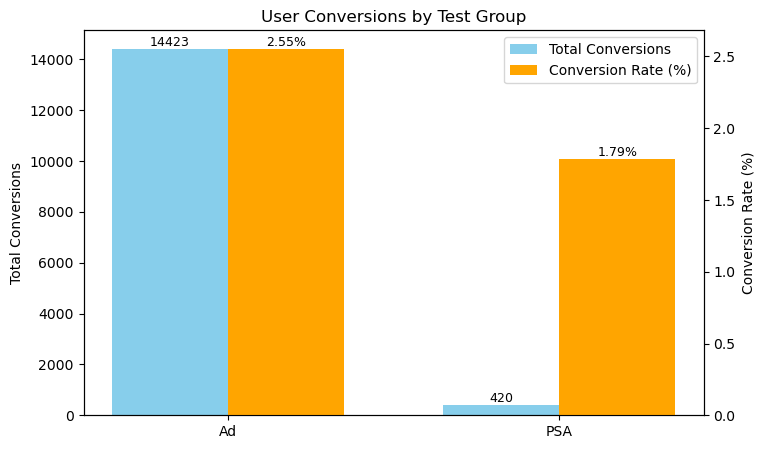

In [58]:
# Data
test_groups = ['Ad', 'PSA']
total_conversions = [14423, 420]
conversion_rate = [2.554656, 1.785411]  # percentage

x = np.arange(len(test_groups))  # the label locations
width = 0.35  # bar width

fig, ax1 = plt.subplots(figsize=(8,5))

# Plot total conversions
bars1 = ax1.bar(x - width/2, total_conversions, width, label='Total Conversions', color='skyblue')
ax1.set_ylabel('Total Conversions')
ax1.set_xticks(x)
ax1.set_xticklabels(test_groups)
ax1.set_title('User Conversions by Test Group')

# Plot conversion rate on secondary axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, conversion_rate, width, label='Conversion Rate (%)', color='orange')
ax2.set_ylabel('Conversion Rate (%)')

# Add legend
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Add value labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height()}', 
             ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}%', 
             ha='center', va='bottom', fontsize=9)

plt.show()

### A/B Analysis Findings: 
The analysis shows that the majority of conversions occurred in the ad group, with 14,423 users converting compared to only 420 in the psa group. In terms of percentages, 97.2% of total conversions came from the ad group, while 2.8% came from the PSA group. 

Examining the conversion rates at the user level, the ad campaign achieved a conversion rate of 2.55%, slightly higher than the PSA group’s 1.79%, indicating that exposure to advertisements had a modest but measurable positive effect on user conversion. 

Overall, the ad campaign appears more effective at driving conversions than the PSA campaign.

## 4. Hypothesis Testing

### Hypothesis 1: Effect of Ad Exposure on Conversion

- Null hypothesis (H₀): Conversion rate is the same for both test groups (ad and psa).
- Alternative hypothesis (H₁): Conversion rate is higher for the ad group compared to the psa group.

In [59]:
from statsmodels.stats.proportion import proportions_ztest

conversion_summary = ab_data.groupby('test_group')['converted'].agg(['sum', 'count'])
conversion_summary

,sum,count
test_group,,
ad,14423,564577
psa,420,23524


In [60]:
# Number of successes (conversions) per group
successes = conversion_summary['sum'].values
# Number of trials (users) per group
nobs = conversion_summary['count'].values

# Z-Test
stat, pval = proportions_ztest(successes, nobs, alternative='larger')  # alternative='larger' because we expect ad > psa

print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4e}")

Z-statistic: 7.3701
P-value: 8.5264e-14


### Hypothesis 1 Findings:
The Z-statistic of 7.37 and the extremely low p-value (8.53 × 10⁻¹⁴) indicate that the difference in conversion rates between the ad and psa groups is highly statistically significant.

Since the p-value is far below the typical 0.05 threshold, we reject the null hypothesis (H₀) that conversion rates are the same. This provides strong evidence that exposure to the advertisement (ad group) significantly increases user conversions compared to the PSA (psa) group.

In other words, the ad campaign is effective at driving conversions.

### Hypothesis 2: Time of Exposure and Conversion
- Null hypothesis (H₀): The day or hour with the most ad exposure (most_ads_day / most_ads_hour) does not affect conversion.
- Alternative hypothesis (H₁): Conversion rate varies depending on the day or hour when the user saw the most ads.

In [61]:
# Create a contingency table
day_conversion_table = pd.crosstab(ab_data['most_ads_day'], ab_data['converted'])
print(day_conversion_table)

# Perform chi-square test
chi2_stat, p_val, dof, expected = chi2_contingency(day_conversion_table)

print(f"Chi2 Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")

converted     False  True 
most_ads_day              
Friday        90551   2057
Monday        84216   2857
Saturday      79941   1719
Sunday        83301   2090
Thursday      81192   1790
Tuesday       75167   2312
Wednesday     78890   2018
Chi2 Statistic: 410.0479
P-value: 1.9322e-85


### Hypothesis 2 Findings:
The results show a strong and statistically significant relationship between the day of highest ad exposure and conversion outcomes. 

With a Chi-square statistic of 410.05 and an extremely small p-value (1.93 × 10⁻⁸⁵), we reject the null hypothesis that conversion is independent of the day on which users saw the most ads. This indicates that conversion rates do vary by day of the week, suggesting that user behaviour and responsiveness to ads differ depending on timing. 

In practical terms, this implies that certain days may be more effective for ad exposure, and optimising campaign timing could improve overall conversion performance.

## 5. LIFT

Lift is a key metric in A/B testing used to quantify the relative improvement of a treatment group compared to a control group. In this project, it will measure how much more effective the ad campaign is at driving conversions compared to the PSA (control) group. 

Rather than focusing only on absolute conversion rates, lift provides a standardised way to understand the percentage increase in performance, making it especially useful for evaluating marketing effectiveness and supporting data-driven decision-making.

In [62]:
ad_rate = 2.554656 / 100
psa_rate = 1.785411 / 100

lift = (ad_rate - psa_rate) / psa_rate
print(f"Lift: {lift:.4f} ({lift*100:.2f}%)")

Lift: 0.4309 (43.09%)


The observed lift of 43.09% indicates that users exposed to the ad campaign were approximately 43% more likely to convert than those in the PSA group. This represents a substantial relative improvement in performance, reinforcing the earlier statistical findings that the ad exposure has a meaningful positive effect on user conversions. While the absolute conversion rates remain relatively low, the magnitude of the lift suggests that the campaign is significantly more effective than the control and could be considered a strong candidate for wider rollout.

## 6. Causal Inference

Did the ads actually cause the increase in conversions, or is something else driving the difference?

In [63]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

### 6.1 Balance Checks

In [73]:
df = ab_data.copy()

# Binary treatment
df['treatment'] = (df['test_group'] == 'ad').astype(int)

# Binary outcome
df['converted'] = df['converted'].astype(int)

#Compare group means
balance_numeric = df.groupby('treatment')[['total_ads', 'most_ads_hour']].mean()
print(balance_numeric)

           total_ads  most_ads_hour
treatment                          
0          24.761138      14.304923
1          24.823365      14.475900


Conclusion: Balanced as there is no evidence of difference between the groups

In [74]:
#T-tests for numeric balance
from scipy.stats import ttest_ind

for col in ['total_ads', 'most_ads_hour']:
    treated = df[df['treatment'] == 1][col]
    control = df[df['treatment'] == 0][col]
    
    stat, pval = ttest_ind(treated, control)
    print(f"{col}: t-stat={stat:.3f}, p-value={pval:.5f}")

total_ads: t-stat=0.214, p-value=0.83061
most_ads_hour: t-stat=5.315, p-value=0.00000


Conclusion: Not balanced because statistically significant difference

In [75]:
#Chi-square tests for categorical balance

contingency = pd.crosstab(df['most_ads_day'], df['treatment'])
chi2, p, _, _ = chi2_contingency(contingency)

print("Chi-square test for most_ads_day:")
print(f"Chi2={chi2:.2f}, p-value={p:.5e}")

Chi-square test for most_ads_day:
Chi2=235.61, p-value=4.84907e-48


Conclusion: strongly not balanced as the distribution of days differs between treatment and control > a violation of randomisation. 

Since the data is unbalanced, we cannot estimate ATE in this instance.

### 6.2 Regression Adjustments with Controls

In [78]:
model_controls = smf.logit(
    'converted ~ treatment + total_ads + most_ads_hour + C(most_ads_day)',
    data=df
).fit()

print(model_controls.summary())

Optimization terminated successfully.
         Current function value: 0.108329
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588091
Method:                           MLE   Df Model:                            9
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.08025
Time:                        15:55:43   Log-Likelihood:                -63708.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -5.1392      0.063    -82.191      0.000

### Covariates
**total_ads** (0.0103): Each additional ad slightly increases log-odds of conversion.

**most_ads_hour** (0.0337): Higher exposure hour slightly increases conversion.

**most_ads_day**: Compared to reference day (Friday):
- Monday, Tuesday have the strongest positive effects (~0.47, 0.44)
- Saturday not significant

This confirms Hypothesis 2: *conversion is day-dependent.*

After adjusting for differences in day of exposure, hour, and number of ads seen, being in the ad group increased the odds of conversion by 46% (OR = 1.46, p < 0.001) compared to PSA. This provides strong evidence that the ad campaign has a causal effect on conversion rates, independent of exposure timing and intensity.

## 7.1 Conclusion (Technical)

The analysis shows that the ad campaign significantly outperforms the PSA control, delivering both a higher conversion rate and a substantial 43% lift in performance. 

After adjusting for differences in exposure timing, hour of day, and total number of ads seen, users in the ad group had 46% higher odds of converting compared to PSA users, providing strong evidence of a causal effect of the ad campaign on conversions. 

Statistical testing confirms that this difference is highly significant and unlikely to be due to chance. Additionally, conversion rates vary by day of ad exposure, indicating that timing influences ad effectiveness. 

Overall, the results support scaling the ad campaign, with further opportunities to optimise performance by targeting high-performing days and hours to maximise conversions.

## 7.2 Conclusion (Non-technical)

The ad campaign causes a significant increase in conversions, with users in the ad group having 46% higher odds of purchasing compared to the PSA group. Conversion rates also vary by day, suggesting that timing affects ad effectiveness. Overall, the campaign is highly effective and should be scaled, with further gains possible by focusing on high-performing days and hours.